# Clase 5 — Aproximación de funciones, DQN y *Policy Gradients*

**Curso:** Aprendizaje por Refuerzo: Fundamentos y Aplicaciones
**Institución:** Universidad Austral — Facultad de Ingeniería (Posgrados)
**Docente:** Dr. Darío Ezequiel Díaz
**Fecha:** 2 de junio de 2026

---

## Resumen del cuaderno

Este cuaderno acompaña la quinta clase del curso y traslada al código el salto desde el mundo **tabular** —donde una casilla almacenaba el valor de cada par estado-acción— hacia el aprendizaje por refuerzo **profundo**, en el que una red neuronal aproxima esos valores o parametriza directamente la política. Abandonamos el *GridWorld* por **CartPole-v1**, un entorno de estado continuo, y abordamos la pregunta vertebradora:

> **¿Cómo aprender a controlar un sistema de estado continuo cuando la tabla deja de ser viable, y qué compromisos estadísticos median entre las grandes familias de algoritmos?**

Los tres protagonistas son **DQN** (red Q profunda, basada en valor), **REINFORCE** (gradiente de política de Monte Carlo) y **PPO** (actor-crítico con objetivo recortado). La estructura sigue los bloques anunciados en la diapositiva del cuaderno:

1. **El entorno CartPole-v1**: el péndulo invertido y su espacio de estados continuo.
2. **DQN desde cero**: repetición de experiencia, red objetivo y el efecto del periodo de sincronización $C$.
3. **REINFORCE**: el gradiente de política de Monte Carlo, con y sin línea base, y la reducción de varianza del gradiente.
4. **PPO con Stable-Baselines3**: el algoritmo actor-crítico de referencia industrial.
5. **Comparación**: los tres algoritmos bajo un eje común de eficiencia muestral, con estadísticas sobre réplicas independientes.

> **Compatibilidad.** El cuaderno se ejecuta en Python 3.10+ y en Google Colab. No requiere GPU: CartPole es ligero y la CPU basta. Las dependencias —`gymnasium`, `torch`, `stable-baselines3`— se instalan en una celda protegida. Siguiendo la convención del curso, cada réplica recibe su propio generador `numpy.random.Generator` derivado de la semilla global, y las desviaciones se reportan con el estimador **insesgado** (`ddof=1`).

> **Sobre la reproducibilidad.** A diferencia de las clases tabulares, la inicialización estocástica de las redes y el no determinismo del cómputo en punto flotante impiden la paridad numérica *exacta* entre ejecuciones o entre lenguajes. La reproducibilidad pasa a ser **estadística**: razonamos sobre medias y dispersiones de varias réplicas, no sobre corridas individuales.

---

### Notación recurrente

| Símbolo | Significado |
|---------|-------------|
| $\hat{q}(s,a;\mathbf{w})$ | Valor de acción aproximado por una red de pesos $\mathbf{w}$ |
| $\mathbf{w}^{-}$ | Pesos de la **red objetivo** (congelados, sincronizados cada $C$ pasos) |
| $\mathcal{D}$ | Memoria de repetición (*replay buffer*) |
| $\pi_\theta(a\mid s)$ | Política parametrizada (*softmax* sobre las acciones) |
| $G_t = \sum_{k\ge 0}\gamma^k R_{t+k+1}$ | Retorno descontado desde el paso $t$ |
| $A^\pi(s,a)=Q^\pi(s,a)-V^\pi(s)$ | Ventaja de la acción $a$ en el estado $s$ |
| $\delta_t = R_{t+1}+\gamma\hat{v}(S_{t+1})-\hat{v}(S_t)$ | TD-error (estimador insesgado de la ventaja) |
| $r_t(\theta)=\pi_\theta/\pi_{\theta_{\text{old}}}$ | Cociente de probabilidades de PPO |

## Bloque 0 — Configuración del entorno

Importamos las bibliotecas y fijamos los parámetros gráficos y de reproducibilidad. La primera celda, *protegida*, instala las dependencias en caso de ausencia (por ejemplo, en una sesión nueva de Colab); puede omitirse sin consecuencias si el entorno ya las posee.

In [1]:
# --- Celda protegida de instalación (Colab / entorno nuevo) ---
# Descomente la línea siguiente si alguna dependencia no está disponible.
# !pip install -q gymnasium "stable-baselines3>=2.0" torch
import importlib.util, subprocess, sys
for paquete in ["gymnasium", "torch", "stable_baselines3"]:
    if importlib.util.find_spec(paquete) is None:
        print(f"Instalando {paquete} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "gymnasium" if paquete=="gymnasium" else
                        ("stable-baselines3" if paquete=="stable_baselines3" else "torch")])
print("Dependencias verificadas.")

Dependencias verificadas.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random, time, warnings
import gymnasium as gym

warnings.filterwarnings("ignore")
%matplotlib inline

DEVICE = torch.device("cpu")  # CartPole no requiere GPU

# --- Reproducibilidad (convención del curso) ---
SEMILLA_GLOBAL = 42

def fijar_semilla(semilla):
    '''Fija las semillas de numpy, random y torch para una replica.'''
    np.random.seed(semilla)
    random.seed(semilla)
    torch.manual_seed(semilla)

# --- Paleta institucional Austral (consistente con Clases 1-4) ---
COLOR_NAVY   = '#1E3A5F'
COLOR_ORANGE = '#D86A2C'
COLOR_TEAL   = '#2E8A99'
COLOR_GRAY   = '#4A4A4A'
COLOR_YELLOW = '#B8860B'
COLOR_RED    = '#C0392B'

plt.rcParams.update({
    'figure.dpi': 100, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.titlecolor': COLOR_NAVY, 'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def media_movil(x, k=10):
    '''Suaviza una serie con una ventana causal de longitud k.'''
    x = np.asarray(x, dtype=float)
    if len(x) < k: return x
    return np.convolve(x, np.ones(k)/k, mode='valid')

print(f"torch {torch.__version__}  |  gymnasium {gym.__version__}")
print(f"Hilos de torch: {torch.get_num_threads()}  |  Semilla global: {SEMILLA_GLOBAL}")
print("Configuración cargada correctamente.")

torch 2.12.0+cu130  |  gymnasium 1.2.3
Hilos de torch: 1  |  Semilla global: 42
Configuración cargada correctamente.


In [3]:
# --- Presupuestos de cómputo ---
# Moderados, para ejecutar en CPU en pocos minutos. Auméntelos para curvas más nítidas.
N_REPLICAS    = 3       # réplicas independientes por algoritmo
DQN_PASOS     = 25000   # pasos de entorno por réplica de DQN
REINF_EPIS    = 300     # episodios por réplica de REINFORCE
PPO_PASOS     = 25000   # pasos de entorno por réplica de PPO
print(f"Réplicas: {N_REPLICAS} | DQN: {DQN_PASOS} pasos | "
      f"REINFORCE: {REINF_EPIS} ep | PPO: {PPO_PASOS} pasos")

Réplicas: 3 | DQN: 25000 pasos | REINFORCE: 300 ep | PPO: 25000 pasos


## Bloque 1 — El entorno CartPole-v1

**CartPole** es el banco de pruebas canónico del control con estado continuo. Un carro se desplaza sobre un riel y sostiene un péndulo invertido mediante una articulación libre; el agente aplica, en cada paso, una fuerza hacia la izquierda o hacia la derecha para impedir que el péndulo caiga.

* **Estado** $s \in \mathbb{R}^4$: posición y velocidad del carro, ángulo y velocidad angular del péndulo. **Continuo** —de cardinalidad infinita—, de modo que la tabla deja de ser definible.
* **Acciones**: dos, discretas (empujar a la izquierda o a la derecha).
* **Recompensa**: $+1$ por cada paso en que el péndulo permanece erguido; el episodio termina si el ángulo o la posición exceden umbrales, o se *trunca* a los 500 pasos. El retorno máximo es, pues, **500**.

Una política aleatoria apenas mantiene el equilibrio unos pocos pasos: ese será nuestro punto de partida.

In [4]:
env = gym.make("CartPole-v1")
DIM_OBS = env.observation_space.shape[0]
N_ACCIONES = env.action_space.n
print(f"Dimensión del estado: {DIM_OBS}  (continuo)")
print(f"Número de acciones:   {N_ACCIONES}  (discreto)")
print(f"Cotas del estado (pos. carro, vel. carro, ángulo, vel. angular):")
print("  bajas:", np.round(env.observation_space.low, 2))
print("  altas:", np.round(env.observation_space.high, 2))

# Retorno de una política puramente aleatoria (línea de base trivial)
rng_demo = np.random.default_rng(SEMILLA_GLOBAL)
retornos_azar = []
for ep in range(50):
    s, _ = env.reset(seed=int(rng_demo.integers(1e6))); G = 0; done = False
    while not done:
        s, r, term, trunc, _ = env.step(int(rng_demo.integers(N_ACCIONES)))
        G += r; done = term or trunc
    retornos_azar.append(G)
env.close()
print(f"\nPolítica aleatoria: retorno medio = {np.mean(retornos_azar):.1f} "
      f"± {np.std(retornos_azar, ddof=1):.1f}  (50 episodios)")

Dimensión del estado: 4  (continuo)
Número de acciones:   2  (discreto)
Cotas del estado (pos. carro, vel. carro, ángulo, vel. angular):
  bajas: [-4.8   -inf -0.42  -inf]
  altas: [4.8   inf 0.42  inf]

Política aleatoria: retorno medio = 24.9 ± 13.1  (50 episodios)


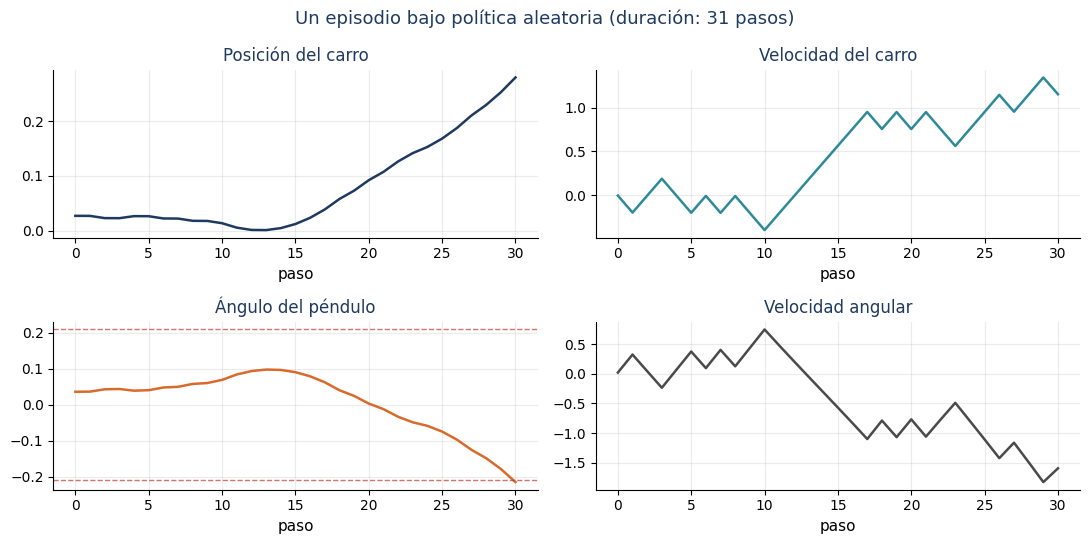

In [5]:
# Visualización de un episodio aleatorio: las cuatro coordenadas del estado en el tiempo
env = gym.make("CartPole-v1")
s, _ = env.reset(seed=SEMILLA_GLOBAL)
traza = [s]; done = False
rng_v = np.random.default_rng(SEMILLA_GLOBAL)
while not done:
    s, r, term, trunc, _ = env.step(int(rng_v.integers(N_ACCIONES)))
    traza.append(s); done = term or trunc
env.close()
traza = np.array(traza)

fig, axes = plt.subplots(2, 2, figsize=(11, 5.5))
nombres = ["Posición del carro", "Velocidad del carro",
           "Ángulo del péndulo", "Velocidad angular"]
colores = [COLOR_NAVY, COLOR_TEAL, COLOR_ORANGE, COLOR_GRAY]
for i, ax in enumerate(axes.flat):
    ax.plot(traza[:, i], color=colores[i], lw=1.8)
    ax.set_title(nombres[i]); ax.set_xlabel("paso"); ax.grid(alpha=0.25)
    if i in (2,):  # umbral de caída del ángulo (~12 grados)
        ax.axhline( 0.209, color=COLOR_RED, ls='--', lw=1, alpha=0.7)
        ax.axhline(-0.209, color=COLOR_RED, ls='--', lw=1, alpha=0.7)
fig.suptitle(f"Un episodio bajo política aleatoria (duración: {len(traza)} pasos)",
             color=COLOR_NAVY, fontsize=13)
plt.tight_layout(); plt.show()

## Bloque 2 — DQN desde cero

**DQN** (Mnih et al., 2015) es Q-Learning con un aproximador neuronal, estabilizado por dos artificios que domestican la *tríada mortal* (aproximación + bootstrapping + off-policy):

1. **Repetición de experiencia** ($\mathcal{D}$): cada transición $(s,a,r,s')$ se almacena en una memoria circular; el entrenamiento consume **minilotes muestreados al azar**, lo que descorrelaciona las muestras y restituye la hipótesis i.i.d. del descenso de gradiente. Solo es lícito porque Q-Learning es *off-policy*.
2. **Red objetivo** ($\mathbf{w}^{-}$): una copia congelada de la red, sincronizada cada $C$ pasos, provee un blanco **estable** y convierte el problema en una regresión supervisada por tramos.

La pérdida que minimizamos es
$$
L(\mathbf{w}) = \mathbb{E}_{(s,a,r,s')\sim\mathcal{D}}\Big[\big(\,r + \gamma\max_{a'}\hat{q}(s',a';\mathbf{w}^{-}) - \hat{q}(s,a;\mathbf{w})\,\big)^2\Big].
$$
Empleamos la pérdida de Huber (`smooth_l1`), más robusta a valores atípicos que el error cuadrático puro.

In [6]:
class RedQ(nn.Module):
    '''Red Q: estado -> vector de valores, uno por accion (una sola pasada).'''
    def __init__(self, dim_obs, n_act, oculta=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_obs, oculta), nn.ReLU(),
            nn.Linear(oculta, oculta), nn.ReLU(),
            nn.Linear(oculta, n_act))
    def forward(self, x):
        return self.net(x)

class MemoriaRepeticion:
    '''Replay buffer circular de capacidad fija.'''
    def __init__(self, capacidad):
        self.buf = deque(maxlen=capacidad)
    def guardar(self, s, a, r, s2, term):
        self.buf.append((s, a, r, s2, term))
    def muestrear(self, n, rng):
        idx = rng.integers(0, len(self.buf), size=n)
        s, a, r, s2, d = zip(*(self.buf[i] for i in idx))
        return (torch.tensor(np.array(s), dtype=torch.float32),
                torch.tensor(a, dtype=torch.int64).unsqueeze(1),
                torch.tensor(r, dtype=torch.float32).unsqueeze(1),
                torch.tensor(np.array(s2), dtype=torch.float32),
                torch.tensor(d, dtype=torch.float32).unsqueeze(1))
    def __len__(self):
        return len(self.buf)

In [7]:
def entrenar_dqn(semilla, n_pasos, C=500, gamma=0.99, lr=1e-3, batch=64,
                 capacidad=10000, inicio_aprendizaje=1000,
                 eps0=1.0, eps_min=0.02, eps_decay=0.995, doble=False):
    '''Entrena DQN sobre CartPole. Devuelve (retornos, pasos_acumulados).
       Si doble=True, aplica el desacople de Double DQN.'''
    fijar_semilla(semilla)
    rng = np.random.default_rng(semilla)
    env = gym.make("CartPole-v1")
    q    = RedQ(DIM_OBS, N_ACCIONES)
    qobj = RedQ(DIM_OBS, N_ACCIONES)
    qobj.load_state_dict(q.state_dict())
    opt  = torch.optim.Adam(q.parameters(), lr=lr)
    mem  = MemoriaRepeticion(capacidad)
    eps  = eps0
    retornos, pasos_acum = [], []
    s, _ = env.reset(seed=semilla); G = 0; t = 0
    while t < n_pasos:
        # epsilon-greedy
        if rng.random() < eps:
            a = int(rng.integers(N_ACCIONES))
        else:
            with torch.no_grad():
                a = int(q(torch.tensor(s, dtype=torch.float32)).argmax())
        s2, r, term, trunc, _ = env.step(a)
        mem.guardar(s, a, r, s2, float(term))   # solo la terminación real corta el bootstrap
        s = s2; G += r; t += 1
        # paso de aprendizaje
        if len(mem) >= inicio_aprendizaje:
            bs, ba, br, bs2, bd = mem.muestrear(batch, rng)
            with torch.no_grad():
                if doble:                               # Double DQN: la red en línea selecciona
                    a_sel = q(bs2).argmax(1, keepdim=True)
                    q_next = qobj(bs2).gather(1, a_sel) # la red objetivo evalúa
                else:                                   # DQN estándar
                    q_next = qobj(bs2).max(1, keepdim=True)[0]
                y = br + gamma * q_next * (1 - bd)
            q_pred = q(bs).gather(1, ba)
            perdida = F.smooth_l1_loss(q_pred, y)
            opt.zero_grad(); perdida.backward(); opt.step()
            if t % C == 0:                              # sincronización de la red objetivo
                qobj.load_state_dict(q.state_dict())
        if term or trunc:
            retornos.append(G); pasos_acum.append(t)
            eps = max(eps_min, eps * eps_decay)
            s, _ = env.reset(); G = 0
    env.close()
    return np.array(retornos), np.array(pasos_acum)

print("Función entrenar_dqn lista.")

Función entrenar_dqn lista.


In [8]:
# Entrenamiento de N_REPLICAS réplicas independientes de DQN estándar
t0 = time.time()
curvas_dqn = []
for k in range(N_REPLICAS):
    semilla = SEMILLA_GLOBAL + k
    ret, pasos = entrenar_dqn(semilla, DQN_PASOS)
    curvas_dqn.append((pasos, ret))
    print(f"  réplica {k+1}/{N_REPLICAS} (semilla {semilla}): "
          f"retorno final ~{ret[-10:].mean():.0f}  [{len(ret)} episodios]")
print(f"DQN entrenado en {time.time()-t0:.1f} s")

  réplica 1/3 (semilla 42): retorno final ~103  [410 episodios]


  réplica 2/3 (semilla 43): retorno final ~167  [400 episodios]


  réplica 3/3 (semilla 44): retorno final ~89  [441 episodios]
DQN entrenado en 162.1 s


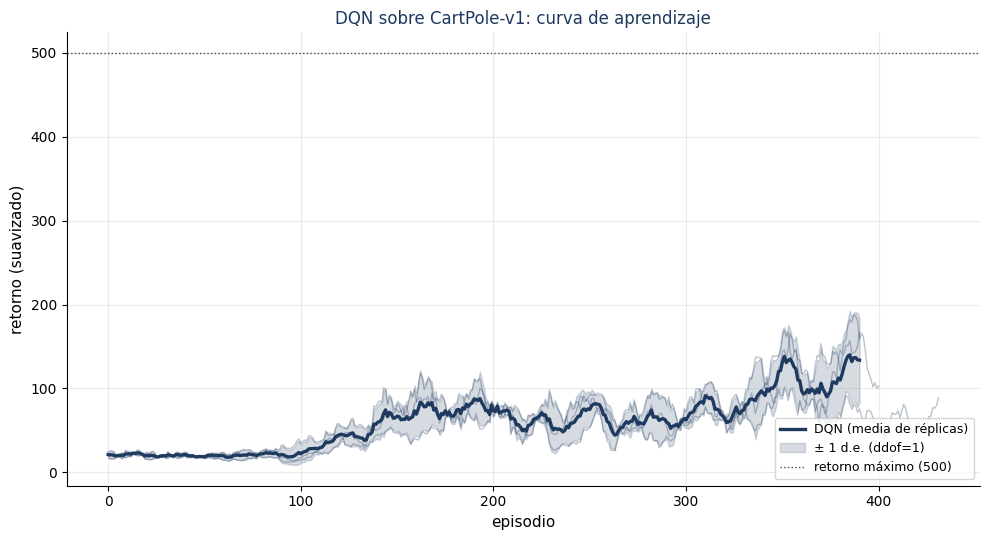

In [9]:
# Curva de aprendizaje de DQN: retorno por episodio (media móvil) y banda entre réplicas
fig, ax = plt.subplots(figsize=(10, 5.5))
ren = []
for pasos, ret in curvas_dqn:
    suav = media_movil(ret, 10)
    ax.plot(suav, color=COLOR_NAVY, alpha=0.30, lw=1)
    ren.append(suav)
L = min(len(r) for r in ren)
M = np.array([r[:L] for r in ren])
ax.plot(M.mean(0), color=COLOR_NAVY, lw=2.4, label='DQN (media de réplicas)')
ax.fill_between(np.arange(L), M.mean(0)-M.std(0, ddof=1), M.mean(0)+M.std(0, ddof=1),
                color=COLOR_NAVY, alpha=0.18, label='± 1 d.e. (ddof=1)')
ax.axhline(500, color=COLOR_GRAY, ls=':', lw=1, label='retorno máximo (500)')
ax.set_xlabel("episodio"); ax.set_ylabel("retorno (suavizado)")
ax.set_title("DQN sobre CartPole-v1: curva de aprendizaje")
ax.legend(loc='lower right'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### 2.1. El efecto del periodo de sincronización $C$

La red objetivo se actualiza cada $C$ pasos. Un $C$ pequeño acerca el comportamiento al de un blanco móvil —rápido pero inestable—; un $C$ grande ofrece blancos muy estables pero desactualizados. Contrastamos dos valores para ilustrar este compromiso, que corresponde al *ejercicio computacional 1* de la clase.

  C= 100: retorno final ~94


  C=1000: retorno final ~53
Estudio de C en 75.5 s


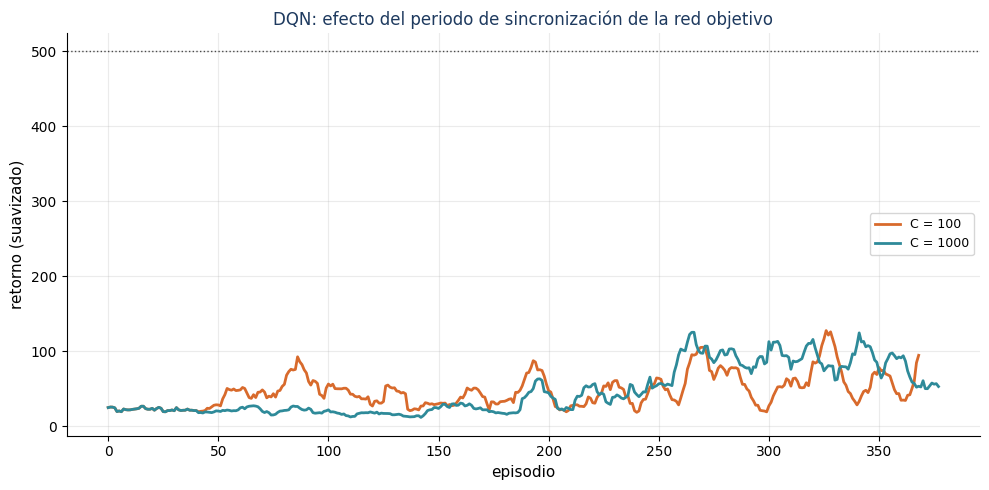

In [10]:
# Comparación del periodo de sincronización C (una réplica por valor, presupuesto reducido)
t0 = time.time()
valores_C = [100, 1000]
curvas_C = {}
for C in valores_C:
    ret, pasos = entrenar_dqn(SEMILLA_GLOBAL, n_pasos=18000, C=C)
    curvas_C[C] = ret
    print(f"  C={C:>4d}: retorno final ~{ret[-10:].mean():.0f}")
print(f"Estudio de C en {time.time()-t0:.1f} s")

fig, ax = plt.subplots(figsize=(10, 5))
for C, col in zip(valores_C, [COLOR_ORANGE, COLOR_TEAL]):
    ax.plot(media_movil(curvas_C[C], 10), color=col, lw=2, label=f'C = {C}')
ax.axhline(500, color=COLOR_GRAY, ls=':', lw=1)
ax.set_xlabel("episodio"); ax.set_ylabel("retorno (suavizado)")
ax.set_title("DQN: efecto del periodo de sincronización de la red objetivo")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## Bloque 3 — REINFORCE: el gradiente de política de Monte Carlo

Cambiamos de paradigma. En lugar de estimar valores y derivar la política por voracidad, **parametrizamos la política directamente** mediante una red *softmax* $\pi_\theta(a\mid s)$ y ascendemos por el gradiente del rendimiento. El teorema del gradiente de política y su estimador de Monte Carlo conducen a **REINFORCE** (Williams, 1992):
$$
\theta \;\leftarrow\; \theta + \alpha\,\gamma^{t}\,G_t\,\nabla_\theta\log\pi_\theta(A_t\mid S_t).
$$
REINFORCE es **insesgado** pero padece **alta varianza**, pues emplea el retorno completo del episodio. El remedio —estadísticamente elegante— consiste en restar una **línea base** $b(s)=\hat{v}(s)$ que no depende de la acción: no introduce sesgo (porque $\mathbb{E}_{a\sim\pi}[b(s)\nabla_\theta\log\pi_\theta]=0$) y reduce la varianza. Lo que multiplica al *score* deja de ser el retorno absoluto y pasa a ser la **ventaja** $G_t-\hat{v}(s)$: cuánto supera la acción a lo esperado en ese estado.

In [11]:
class RedPolitica(nn.Module):
    '''Política softmax: estado -> logits sobre las acciones.'''
    def __init__(self, dim, n_act, oculta=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, oculta), nn.ReLU(),
                                 nn.Linear(oculta, n_act))
    def forward(self, x):
        return self.net(x)

class RedValor(nn.Module):
    '''Crítico de valor para la línea base: estado -> escalar v(s).'''
    def __init__(self, dim, oculta=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, oculta), nn.ReLU(),
                                 nn.Linear(oculta, 1))
    def forward(self, x):
        return self.net(x)

def entrenar_reinforce(semilla, n_episodios, usar_baseline=False,
                       gamma=0.99, lr=1e-2):
    '''REINFORCE con o sin línea base. Devuelve (retornos, normas_grad, pasos_acum).
       normas_grad registra la norma del gradiente de la política por episodio,
       cuyo comportamiento ilustra la reducción de varianza.'''
    fijar_semilla(semilla)
    env = gym.make("CartPole-v1")
    pol  = RedPolitica(DIM_OBS, N_ACCIONES); optp = torch.optim.Adam(pol.parameters(), lr=lr)
    if usar_baseline:
        val = RedValor(DIM_OBS); optv = torch.optim.Adam(val.parameters(), lr=lr)
    retornos, normas_grad, pasos_acum = [], [], []
    total = 0
    for ep in range(n_episodios):
        s, _ = env.reset(seed=semilla + ep)
        logps, recompensas, valores = [], [], []
        done = False
        while not done:
            logits = pol(torch.tensor(s, dtype=torch.float32))
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample(); logps.append(dist.log_prob(a))
            if usar_baseline:
                valores.append(val(torch.tensor(s, dtype=torch.float32)))
            s, r, term, trunc, _ = env.step(int(a)); done = term or trunc
            recompensas.append(r)
        # retornos descontados G_t
        G = 0.0; Gs = []
        for r in reversed(recompensas):
            G = r + gamma * G; Gs.insert(0, G)
        Gs = torch.tensor(Gs, dtype=torch.float32)
        logps = torch.stack(logps)
        total += len(recompensas)
        retornos.append(sum(recompensas)); pasos_acum.append(total)
        if usar_baseline:
            v = torch.stack(valores).squeeze(-1)
            ventaja = Gs - v.detach()
            perdida_pol = -(logps * ventaja).sum()
            perdida_val = F.mse_loss(v, Gs)
            optp.zero_grad(); perdida_pol.backward()
            gn = torch.sqrt(sum((p.grad**2).sum() for p in pol.parameters()))
            normas_grad.append(float(gn)); optp.step()
            optv.zero_grad(); perdida_val.backward(); optv.step()
        else:
            perdida_pol = -(logps * Gs).sum()
            optp.zero_grad(); perdida_pol.backward()
            gn = torch.sqrt(sum((p.grad**2).sum() for p in pol.parameters()))
            normas_grad.append(float(gn)); optp.step()
    env.close()
    return np.array(retornos), np.array(normas_grad), np.array(pasos_acum)

print("Funciones de REINFORCE listas.")

Funciones de REINFORCE listas.

In [12]:
# Entrenamiento: REINFORCE sin y con línea base, N_REPLICAS réplicas cada variante
t0 = time.time()
curvas_sin, curvas_con = [], []
grad_sin, grad_con = [], []
for k in range(N_REPLICAS):
    sem = SEMILLA_GLOBAL + k
    r0, g0, p0 = entrenar_reinforce(sem, REINF_EPIS, usar_baseline=False)
    r1, g1, p1 = entrenar_reinforce(sem, REINF_EPIS, usar_baseline=True)
    curvas_sin.append((p0, r0)); curvas_con.append((p1, r1))
    grad_sin.append(g0); grad_con.append(g1)
    print(f"  réplica {k+1}: sin línea base ~{r0[-10:].mean():.0f} | "
          f"con línea base ~{r1[-10:].mean():.0f}")
print(f"REINFORCE entrenado en {time.time()-t0:.1f} s")

  réplica 1: sin línea base ~116 | con línea base ~500


  réplica 2: sin línea base ~47 | con línea base ~500


  réplica 3: sin línea base ~143 | con línea base ~9
REINFORCE entrenado en 278.7 s


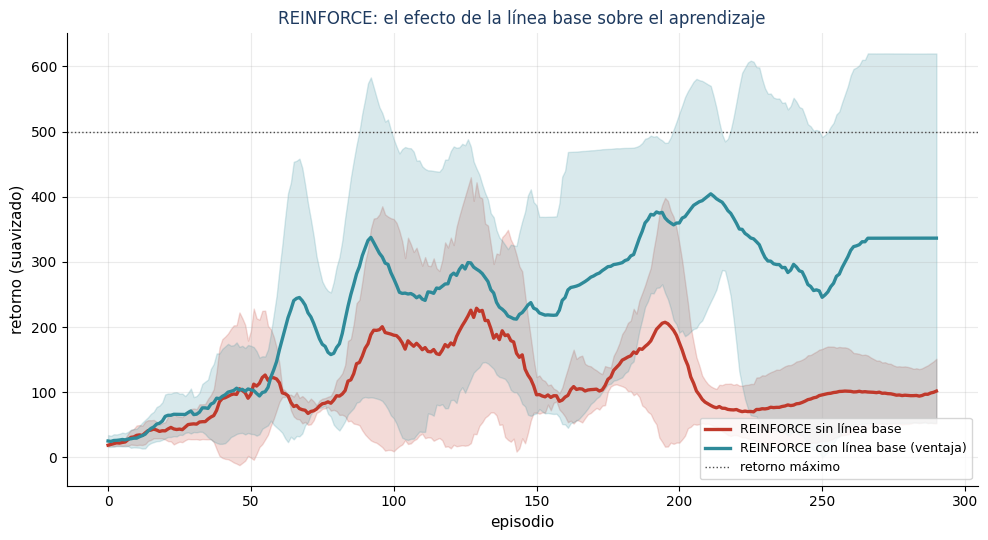

In [13]:
# Curvas comparadas: REINFORCE con vs sin línea base
fig, ax = plt.subplots(figsize=(10, 5.5))
def banda(curvas, color, etiqueta):
    series = [media_movil(r, 10) for _, r in curvas]
    L = min(map(len, series)); M = np.array([s[:L] for s in series])
    ax.plot(M.mean(0), color=color, lw=2.4, label=etiqueta)
    ax.fill_between(np.arange(L), M.mean(0)-M.std(0, ddof=1), M.mean(0)+M.std(0, ddof=1),
                    color=color, alpha=0.18)
banda(curvas_sin, COLOR_RED,  'REINFORCE sin línea base')
banda(curvas_con, COLOR_TEAL, 'REINFORCE con línea base (ventaja)')
ax.axhline(500, color=COLOR_GRAY, ls=':', lw=1, label='retorno máximo')
ax.set_xlabel("episodio"); ax.set_ylabel("retorno (suavizado)")
ax.set_title("REINFORCE: el efecto de la línea base sobre el aprendizaje")
ax.legend(loc='lower right'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### 3.1. Cuantificación de la varianza del gradiente

La promesa teórica de la línea base es **reducir la varianza** del estimador del gradiente sin introducir sesgo. Lo verificamos empíricamente comparando la dispersión de la norma del gradiente de la política entre ambas variantes (*ejercicio computacional 2*). Reportamos la varianza con el estimador insesgado (`ddof=1`).

Varianza de la norma del gradiente (media sobre réplicas, ddof=1):
  sin línea base : 1153021.1
  con línea base : 382410.0
  reducción      : 67 %


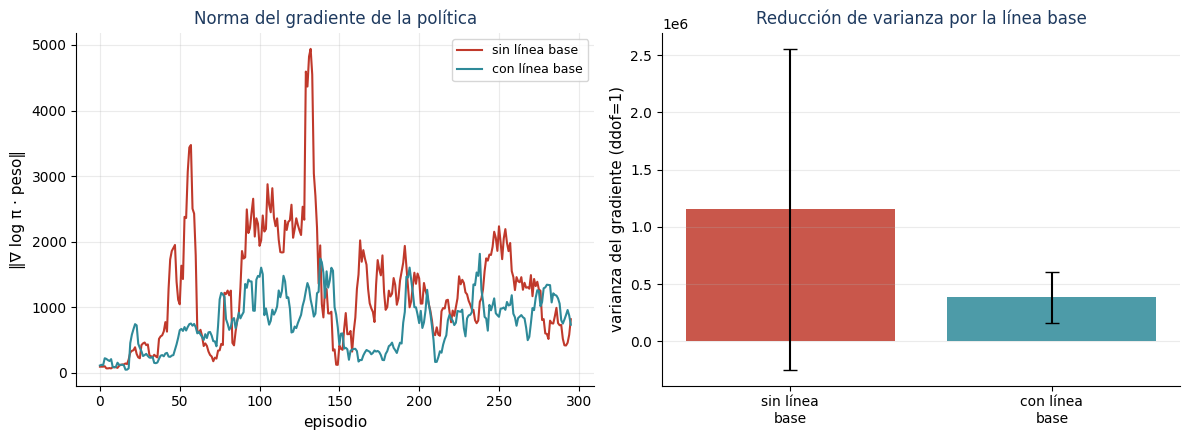

In [14]:
# Varianza de la norma del gradiente: con vs sin línea base
# (se compara sobre la primera mitad del entrenamiento, antes de la saturación en 500)
def var_grad(lista, frac=0.5):
    vs = []
    for g in lista:
        m = int(len(g)*frac)
        vs.append(np.var(g[:m], ddof=1))
    return np.array(vs)

v_sin = var_grad(grad_sin); v_con = var_grad(grad_con)
print("Varianza de la norma del gradiente (media sobre réplicas, ddof=1):")
print(f"  sin línea base : {v_sin.mean():.1f}")
print(f"  con línea base : {v_con.mean():.1f}")
print(f"  reducción      : {100*(1 - v_con.mean()/v_sin.mean()):.0f} %")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# (a) trazas de la norma del gradiente de una réplica
axes[0].plot(media_movil(grad_sin[0], 5), color=COLOR_RED,  lw=1.5, label='sin línea base')
axes[0].plot(media_movil(grad_con[0], 5), color=COLOR_TEAL, lw=1.5, label='con línea base')
axes[0].set_xlabel("episodio"); axes[0].set_ylabel("‖∇ log π · peso‖")
axes[0].set_title("Norma del gradiente de la política"); axes[0].legend(); axes[0].grid(alpha=0.25)
# (b) varianza comparada
axes[1].bar(['sin línea\nbase', 'con línea\nbase'], [v_sin.mean(), v_con.mean()],
            color=[COLOR_RED, COLOR_TEAL], alpha=0.85,
            yerr=[v_sin.std(ddof=1), v_con.std(ddof=1)], capsize=5)
axes[1].set_ylabel("varianza del gradiente (ddof=1)")
axes[1].set_title("Reducción de varianza por la línea base"); axes[1].grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

## Bloque 4 — PPO con Stable-Baselines3

**PPO** (Schulman et al., 2017) es un método **actor-crítico** que limita cuánto cambia la política por actualización mediante un objetivo **recortado**:
$$
L^{\mathrm{CLIP}}(\theta)=\mathbb{E}_t\big[\min\big(r_t(\theta)\hat{A}_t,\ \operatorname{clip}(r_t(\theta),1-\epsilon,1+\epsilon)\hat{A}_t\big)\big],
\qquad r_t(\theta)=\frac{\pi_\theta(A_t\mid S_t)}{\pi_{\theta_{\text{old}}}(A_t\mid S_t)}.
$$
El operador $\min$ toma siempre la cota pesimista, salvaguardando frente a pasos temerarios. Con $\epsilon\approx 0{,}2$ la política evoluciona con prudencia. Empleamos la implementación de referencia de **Stable-Baselines3**, contrastando el algoritmo artesanal con una versión industrial.

In [15]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

class RegistroRetorno(BaseCallback):
    '''Captura el retorno y el número de pasos al cierre de cada episodio.'''
    def __init__(self):
        super().__init__(); self.retornos = []; self.pasos = []
    def _on_step(self):
        for info in self.locals["infos"]:
            if "episode" in info:
                self.retornos.append(info["episode"]["r"])
                self.pasos.append(self.num_timesteps)
        return True

def entrenar_ppo(semilla, n_pasos):
    '''Entrena PPO sobre CartPole. Devuelve (pasos, retornos).'''
    env = Monitor(gym.make("CartPole-v1"))
    cb = RegistroRetorno()
    modelo = PPO("MlpPolicy", env, seed=semilla, verbose=0,
                 n_steps=1024, batch_size=64, gae_lambda=0.95,
                 clip_range=0.2, gamma=0.99)
    modelo.learn(total_timesteps=n_pasos, callback=cb)
    env.close()
    return np.array(cb.pasos), np.array(cb.retornos)

print("Función entrenar_ppo lista.")

Función entrenar_ppo lista.


In [16]:
# Entrenamiento de N_REPLICAS réplicas de PPO
t0 = time.time()
curvas_ppo = []
for k in range(N_REPLICAS):
    sem = SEMILLA_GLOBAL + k
    pasos, ret = entrenar_ppo(sem, PPO_PASOS)
    curvas_ppo.append((pasos, ret))
    print(f"  réplica {k+1}/{N_REPLICAS} (semilla {sem}): "
          f"retorno final ~{ret[-10:].mean():.0f}  [{len(ret)} episodios]")
print(f"PPO entrenado en {time.time()-t0:.1f} s")

  réplica 1/3 (semilla 42): retorno final ~388  [234 episodios]


  réplica 2/3 (semilla 43): retorno final ~301  [234 episodios]


  réplica 3/3 (semilla 44): retorno final ~226  [259 episodios]
PPO entrenado en 97.1 s


## Bloque 5 — Comparación: eficiencia muestral y estabilidad

Confrontamos los tres algoritmos sobre un **eje común de pasos de entorno**, la moneda honesta de la eficiencia muestral. Para cada uno interpolamos el retorno (suavizado) sobre una rejilla de pasos compartida y promediamos las réplicas, con bandas de $\pm 1$ desviación estándar insesgada. Cerramos con una tabla de estadísticas finales.

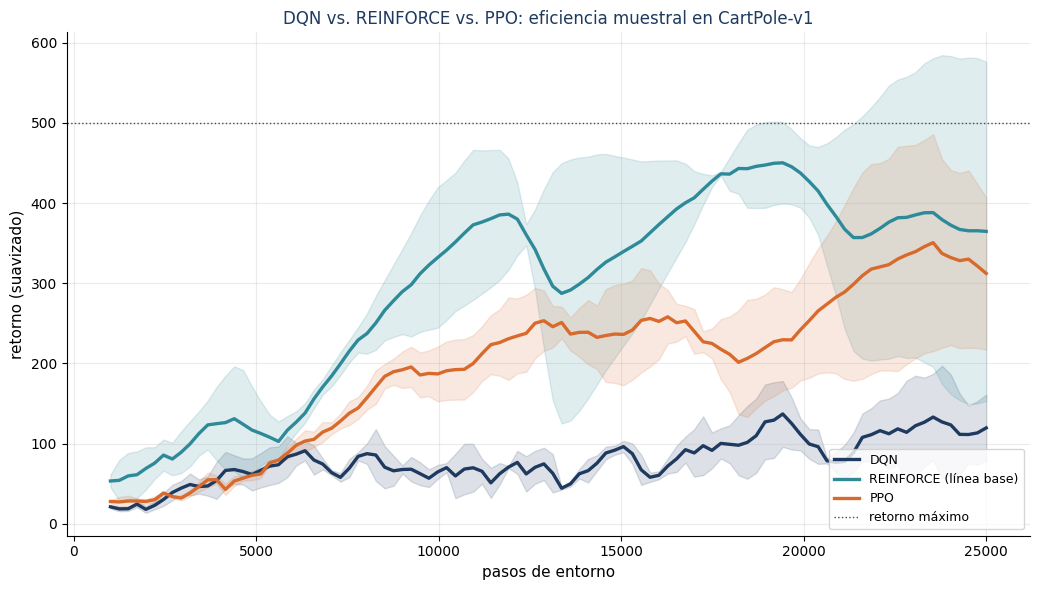

In [17]:
# Interpolación del retorno sobre una rejilla común de pasos de entorno
rejilla = np.linspace(1000, min(DQN_PASOS, PPO_PASOS), 100)

def interpolar(curvas, k_suav=10):
    series = []
    for pasos, ret in curvas:
        ret_s = media_movil(ret, k_suav)
        pasos_s = pasos[len(pasos)-len(ret_s):]
        series.append(np.interp(rejilla, pasos_s, ret_s))
    M = np.array(series)
    return M.mean(0), M.std(0, ddof=1)

m_dqn, s_dqn = interpolar(curvas_dqn)
m_ppo, s_ppo = interpolar(curvas_ppo)
m_rei, s_rei = interpolar(curvas_con)   # REINFORCE con línea base (la variante competitiva)

fig, ax = plt.subplots(figsize=(10.5, 6))
for m, sd, col, et in [(m_dqn, s_dqn, COLOR_NAVY, 'DQN'),
                       (m_rei, s_rei, COLOR_TEAL, 'REINFORCE (línea base)'),
                       (m_ppo, s_ppo, COLOR_ORANGE, 'PPO')]:
    ax.plot(rejilla, m, color=col, lw=2.4, label=et)
    ax.fill_between(rejilla, m-sd, m+sd, color=col, alpha=0.15)
ax.axhline(500, color=COLOR_GRAY, ls=':', lw=1, label='retorno máximo')
ax.set_xlabel("pasos de entorno"); ax.set_ylabel("retorno (suavizado)")
ax.set_title("DQN vs. REINFORCE vs. PPO: eficiencia muestral en CartPole-v1")
ax.legend(loc='lower right'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

In [18]:
# Tabla de estadísticas finales (media ± desviación insesgada sobre réplicas)
def retorno_final(curvas, n=10):
    return np.array([ret[-n:].mean() for _, ret in curvas])

resumen = {
    'DQN':                    retorno_final(curvas_dqn),
    'REINFORCE (sin base)':   retorno_final(curvas_sin),
    'REINFORCE (con base)':   retorno_final(curvas_con),
    'PPO':                    retorno_final(curvas_ppo),
}
print(f"{'Algoritmo':<24}{'Retorno final':>16}{'D.E. (ddof=1)':>16}")
print("-"*56)
for nombre, vals in resumen.items():
    print(f"{nombre:<24}{vals.mean():>16.1f}{vals.std(ddof=1):>16.1f}")
print("-"*56)
print(f"(Promedios sobre {N_REPLICAS} réplicas; retorno máximo alcanzable = 500.)")

Algoritmo                  Retorno final   D.E. (ddof=1)
--------------------------------------------------------
DQN                                119.7            41.7
REINFORCE (sin base)               101.8            49.6
REINFORCE (con base)               336.4           283.3
PPO                                305.1            80.8
--------------------------------------------------------
(Promedios sobre 3 réplicas; retorno máximo alcanzable = 500.)


## Bloque 6 — Síntesis y ejercicios propuestos

### Lo que el código mostró

* **DQN** convierte Q-Learning en un método viable sobre estado continuo gracias a la **repetición de experiencia** y la **red objetivo**; su eficiencia muestral es alta porque reutiliza cada transición, pero su estabilidad depende de hiperparámetros como el periodo $C$.
* **REINFORCE** ilustra, en estado puro, el gradiente de política y su **alta varianza**. La **línea base** —el embrión del crítico— reduce esa varianza sin sesgo, como se verificó empíricamente, y acelera y estabiliza el aprendizaje.
* **PPO** materializa la madurez actor-crítico: su recorte prudente entrega la curva más estable, lo que explica su condición de algoritmo de referencia en la práctica.

> **Recordatorio metodológico.** Las curvas se promedian sobre réplicas con desviación insesgada (`ddof=1`). Una conclusión que solo se sostiene en una semilla afortunada no es un efecto, sino ruido: razonar sobre distribuciones de desempeño es la respuesta estadística correcta a la irreproducibilidad exacta del cómputo profundo.

### Ejercicios propuestos

1. **Teórico 1.** Demuestre que una línea base $b(s)$ independiente de la acción no introduce sesgo en el gradiente de política, partiendo de $\mathbb{E}_{a\sim\pi}[\nabla_\theta\log\pi_\theta(a\mid s)]=0$.
2. **Teórico 2.** Derive la equivalencia entre minimizar la pérdida de DQN con red objetivo fija y un paso de Q-Learning, identificando el papel de $\mathbf{w}^{-}$.
3. **Computacional 1.** Amplíe el estudio del periodo $C$ y de la capacidad del *replay buffer* sobre la estabilidad de la curva de retorno; promedie sobre varias réplicas.
4. **Computacional 2.** Extienda la cuantificación de la reducción de varianza del gradiente: estudie su dependencia del factor de descuento $\gamma$ y del tamaño de la red del crítico.
5. **Integrador.** Contraste DQN, REINFORCE y PPO bajo idéntico presupuesto de pasos; discuta eficiencia muestral, estabilidad y rendimiento final con intervalos de confianza.

> **Entrega evaluativa (Unidad 4 — componente de RL profundo).** Plazo: **8 de junio, 23:59 hs**. Resolver el ejercicio teórico 1 y el computacional 1, más una de las dos opciones avanzadas (computacional 2 o integrador). Entregar el PDF junto al **notebook ejecutado** (con sus salidas visibles) por el aula virtual.

---

*Fin del cuaderno de la Clase 5. Las dudas sobre las derivaciones, la estabilización de DQN o el objetivo de PPO se canalizan por el foro específico de la clase.*

**Dr. Darío Ezequiel Díaz** — Universidad Austral, Facultad de Ingeniería.